In [1]:
import random
import copy
import torch
import pickle
import os
import matplotlib.pyplot as plt
import numpy as np

from collections import defaultdict

from causal_gym import HumanoidMazePCH
from causal_rl.algo.imitation.imitate import *
from causal_rl.algo.imitation.finetune import *
from causal_rl.algo.imitation.gail.core_net import *
from causal_rl.algo.imitation.gail.causal_gail import *
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "figure.dpi": 150,
})

<frozen importlib._bootstrap>:241: RuntimeWarning: Your system is avx2 capable but pygame was not built with support for it. The performance of some of your blits could be adversely affected. Consider enabling compile time detection with environment variables like PYGAME_DETECT_AVX2=1 if you are compiling without cross compilation.
/home/et2842/miniconda3/envs/causalenv/lib/python3.11/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [ ]:
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

'cpu'

In [3]:
num_steps = 2000
hidden_dims = {'C'}

In [4]:
# for eval: corrupted W, V hidden
eval_env = HumanoidMazePCH(num_steps=num_steps, expert_mode=False)

In [5]:
# load model
MODEL_PATH = '/home/et2842/causal/causalrl/models/cbc_hummed_v2.pt'
ckpt = torch.load(MODEL_PATH, map_location=device, weights_only=False)

action_bounds = (ckpt['action_bounds_low'], ckpt['action_bounds_high'])

causal_bc_model = ContinuousPolicyNN(
    input_dim=ckpt['input_dim'],
    action_dim=ckpt['num_actions'],
    hidden_dim=ckpt['hidden_dim'],
    num_blocks=ckpt['num_blocks'],
    dropout=ckpt['dropout'],
    layernorm=ckpt['layernorm'],
    final_tanh=ckpt['final_tanh'],
    action_bounds=action_bounds,
).to(device)

causal_bc_model.load_state_dict(ckpt['state_dict'])
causal_bc_model.eval()

slots = ckpt['slots']
Z_trim = ckpt['Z_trim']
dims = ckpt['dims']
lookback = ckpt['lookback']

causal_bc_policy = shared_policy_fn_long_horizon(causal_bc_model, slots, Z_trim, continuous=True, device=device)
causal_bc_policies = make_shared_policy_dict(causal_bc_policy)

In [ ]:
num_eval_eps = 1000

causal_bc_returns = collect_imitator_trajectories(
    env=eval_env,
    policies=causal_bc_policies,
    num_episodes=num_eval_eps,
    max_steps=num_steps,
    hidden_dims=hidden_dims,
    show_progress=True
)

len(causal_bc_returns)

Starting episode 1/100...
  Episode 1 ended at step 2000 (terminated: False, truncated: True).
Starting episode 2/100...
  Episode 2 ended at step 1375 (terminated: True, truncated: False).
Starting episode 3/100...
  Episode 3 ended at step 2000 (terminated: False, truncated: True).
Starting episode 4/100...
  Episode 4 ended at step 2000 (terminated: False, truncated: True).
Starting episode 5/100...
  Episode 5 ended at step 1675 (terminated: True, truncated: False).
Starting episode 6/100...
  Episode 6 ended at step 2000 (terminated: False, truncated: True).
Starting episode 7/100...
  Episode 7 ended at step 1817 (terminated: True, truncated: False).
Starting episode 8/100...
  Episode 8 ended at step 1653 (terminated: True, truncated: False).
Starting episode 9/100...
  Episode 9 ended at step 2000 (terminated: False, truncated: True).
Starting episode 10/100...
  Episode 10 ended at step 2000 (terminated: False, truncated: True).
Starting episode 11/100...
  Episode 11 ended at

186283

In [7]:
causal_bc_episode_rewards = defaultdict(float)
for rec in causal_bc_returns:
    ep = rec['episode']
    causal_bc_episode_rewards[ep] += float(rec['reward'])

causal_bc_rewards = [causal_bc_episode_rewards[e] for e in range(num_eval_eps)]
sum(causal_bc_rewards) / num_eval_eps

-614.1494557613212

In [8]:
mean_reward = np.mean(causal_bc_rewards)
std_reward = np.std(causal_bc_rewards)

print(f"E[Y]          = {mean_reward:.4f}")
print(f"Std[Y]        = {std_reward:.4f}")
print(f"E[Y] ± Std[Y] = {mean_reward:.4f} ± {std_reward:.4f}")

E[Y]          = -614.1495
Std[Y]        = 186.7930
E[Y] ± Std[Y] = -614.1495 ± 186.7930


In [9]:
# success rate: % of episodes solved in under 1000 steps
ep_lengths = defaultdict(int)
for rec in causal_bc_returns:
    ep_lengths[rec['episode']] += 1

lengths = np.array([ep_lengths[e] for e in range(num_eval_eps)])
successes = lengths < num_steps
success_rate = successes.mean()
se = np.sqrt(success_rate * (1 - success_rate) / num_eval_eps)

print(f"Success rate   = {100 * success_rate:.2f}% ({successes.sum()}/{num_eval_eps} episodes)")
print(f"Std error      = {100 * se:.2f}%")

Success rate   = 18.00% (18/100 episodes)
Std error      = 3.84%


In [10]:
# successful episode lengths
success_lengths = lengths[successes]

if len(success_lengths) > 0:
    print(f"Successful episode lengths (n={len(success_lengths)}):")
    print(f"  Mean   = {np.mean(success_lengths):.2f}")
    print(f"  Std    = {np.std(success_lengths):.2f}")
    print(f"  Median = {np.median(success_lengths):.0f}")
    print(f"  Min    = {np.min(success_lengths)}")
    print(f"  Max    = {np.max(success_lengths)}")
    print(f"  25th%  = {np.percentile(success_lengths, 25):.0f}")
    print(f"  75th%  = {np.percentile(success_lengths, 75):.0f}")
else:
    print("No episodes were solved.")

Successful episode lengths (n=18):
  Mean   = 1237.94
  Std    = 415.25
  Median = 1320
  Min    = 566
  Max    = 1824
  25th%  = 817
  75th%  = 1615


In [11]:
from matplotlib.collections import LineCollection

def get_episode_xy_from_records(records, episode_id: int):
    ep = [r for r in records if r['episode'] == episode_id]
    ep = sorted(ep, key=lambda r: r['step'])
    xs, ys = [], []
    for r in ep:
        pos = r['obs']['P'][-1]
        xs.append(pos[0])
        ys.append(pos[1])
    return np.array(xs), np.array(ys)

def plot_ant_xy_trajectory(records, episode_id: int = 0, ax=None, title_prefix='HumanoidMaze Medium'):
    xs, ys = get_episode_xy_from_records(records, episode_id)
    T = len(xs)

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    else:
        fig = ax.figure

    points = np.array([xs, ys]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    t_norm = np.linspace(0, 1, T - 1)
    lc = LineCollection(segments, cmap='twilight', norm=plt.Normalize(0, 1))
    lc.set_array(t_norm)
    lc.set_linewidth(5.0)
    ax.add_collection(lc)

    ax.scatter(xs[0], ys[0], s=90, c="#2c30a0", marker='o', edgecolors='black', linewidths=0.8, zorder=5, label='Start')
    ax.scatter(xs[-1], ys[-1], s=90, c='#d62728', marker='X', edgecolors='black', linewidths=0.8, zorder=5, label='End')

    # cbar = fig.colorbar(lc, ax=ax, fraction=0.046, pad=0.04)
    # cbar.set_label('Time (normalized)')

    ax.set_aspect('equal', 'box')
    ax.set_xlabel('$x$ position')
    ax.set_ylabel('$y$ position')
    ax.set_title(f'{title_prefix} ({T} steps)', fontsize=14)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    ax.xaxis.grid(True, linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)
    ax.legend(loc='upper left', framealpha=0.9, edgecolor='gray')
    return fig, ax

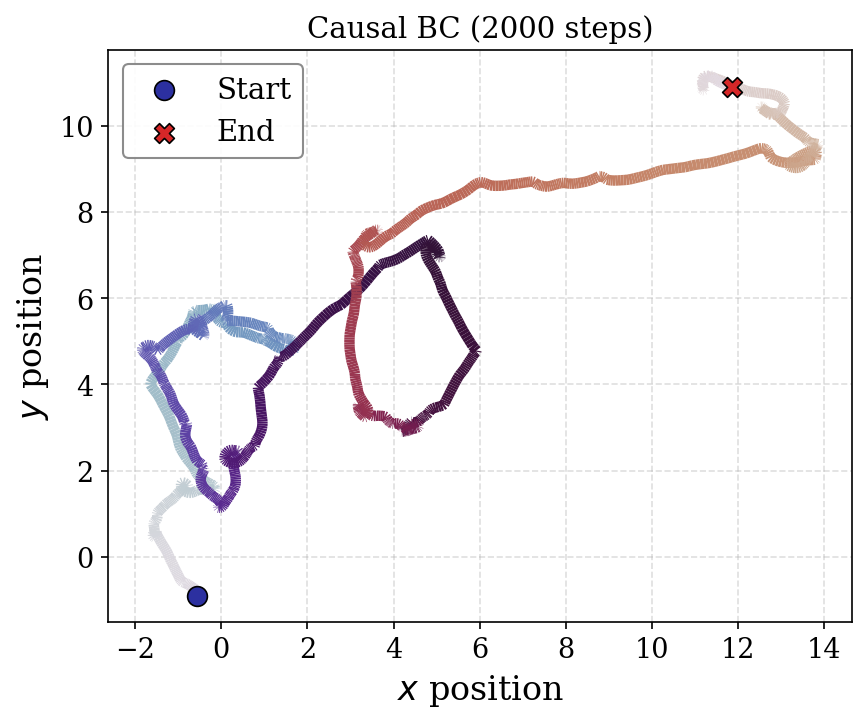

In [12]:
# trajectory heatmaps for 1 random episode
rng = np.random.default_rng()
sample_eps = rng.choice(num_eval_eps, size=1, replace=False)

fig, axes = plt.subplots(1, 1, figsize=(6, 6))
for ax, ep_id in zip([axes], sample_eps):
    plot_ant_xy_trajectory(causal_bc_returns, episode_id=int(ep_id), ax=ax,
                           title_prefix='Causal BC')
plt.tight_layout()
fig.savefig('/home/et2842/causal/causalrl/examples/experiments/plots/humanoidmaze-medium/hummed_cbc_traj.pdf', dpi=300, bbox_inches='tight')
plt.show()